# v19 — бессеточный нейрооператор устойчивости: ветвь upwind-LSFVP (v13) + SubspaceNet + Рэлей–Ритц, валидация точным спектром якобиана

**Идея.** Сеть представляет только гладкие объекты: (1) гладкую ветвь u_s(z,t) — берём **как есть** из v13 (upwind-LSFVP, глобальная сеть, автоград ∂/∂t; огибающая 0.31 %); (2) **инвариантное подпространство** Q(z,t) ∈ ℝ^{(N+2)×K} линеаризованного отображения шага. Ведущая мода (инкремент α, частота ω) извлекается **линейной алгеброй** K×K (Рэлей–Ритц) — выбор моды не делается градиентным спуском (по Deep Eigenspace Network, arXiv 2512.20058; контроль спектром — как в нейрооператорном фреймворке устойчивости arXiv 2604.19465).

**Линеаризуемый оператор — BE-шаг v13b на облаке частиц** (донорные МНК-потоки, интегральный импульс, состояние `U = (h на частицах, G_in, ∫G dz)`):
```
R(U₁, U₀; t) = [ R_E (энергия, N шт.) ; R_M (интегральный импульс) ; R_IG = ∫G₁ − Σ G₁ V_i ]  — квадратная система (N+2)
A = ∂R/∂U₁ , B = ∂R/∂U₀ ,   отображение шага  J = −A⁻¹B ,   μ — его собственные числа,  λ = ln μ / Δt,  α = Re λ, ω = Im λ
```
**Точный эталон (v15 на облаке):** `eig(J)` (130×130) на ветви — (a) TempaFV-ветвь, перенесённая на облако (контроль оператора), (b) ветвь сети v13 (контроль ветви). Ворота физики: t*(α=0) vs v15 1804 s / TempaFV onset 1801 s; период 2π/ω vs 5.7 s (v15: 4.7–5.3 s).

**SubspaceNet.** Q(z,t): RFF(z)+t → MLP → K функций для h-части; малый MLP(t) → 2K скаляров для (G_in, ∫G)-частей; ортонормировка QR на облаке (жёстко). Лосс инвариантности (матрично: только A·q, B·q):
```
S = −(QᵀAQ)⁻¹(QᵀBQ)   (K×K Ритц),      L = ‖ B·Q + A·Q·S ‖²_F / ‖ B·Q ‖²_F
Ритц: B_K c = −μ A_K c  →  μ_k ,  ведущая = max Re ln μ ;   угол подпространства к точному ведущему вектору  sinΘ
```
**Ворота метода:** |t*_Ритц − t*_eig| ≤ 10 s; |ω_Ритц/ω_eig − 1| ≤ 5 % у порога; sinΘ ≤ 0.05; **бессеточность**: Q, обученная на регулярном облаке N=128, даёт те же α, ω на джиттер-облаке и на N=200 (оператор пересобран, сеть не переобучается).


In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [9]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


## Build the physics object (no model needed — FV reuses eos25 / distributed_friction / NQ_prime)

In [10]:
physics = Physics(
    model=None,            # FV solver uses no network
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)
print('physics ready. G0*=%.4f  dpi*=%.3f  Fr=%.4f  kin=%.3g  kout=%.3g  t_end*=%.1f'
      % (case.G0_star, case.dpi_star, case.Fr, case.kin, case.kout, case.t_end_star))

physics ready. G0*=2.6989  dpi*=93.851  Fr=0.0963  kin=20  kout=20  t_end*=846.1


## Smooth EOS tail extension

The IAPWS density spline is calibrated for `h_abs ∈ [0.75, 4.2] MJ/kg`. When the flow nearly
stagnates, the outlet enthalpy leaves that range and the raw spline **extrapolates polynomial
garbage** (wild `rho/chi`) — that is what blew the tail up into the unphysical saw-tooth.

Fix (no recalibration, closures untouched inside the validity range): replace `eos25` with a
version that transitions **C¹-continuously** at the range edges to a hyperbolic tail
`rho(h) = rho_e / (1 + a·(h − h_e))`, `a = −chi_e/rho_e`, which matches both `rho` and `drho/dh`
at the edge and decays like `1/h` — the ideal-gas asymptote at fixed pressure — so `rho` stays
positive and `chi_h` bounded for **any** enthalpy the solver visits. The viscosity spline has the
same validity problem, so its enthalpy input is clamped to the same range (gas-phase viscosity is
nearly flat there).

In [11]:
class ExtendedEOS25:
    """C1-smooth extension of the spline EOS beyond its enthalpy validity range.

    Inside [h_lo, h_hi] (h* units): the IAPWS spline unchanged. Above h_hi: a
    hyperbolic tail rho(h) = rho_e / (1 + a (h - h_e)), a = -chi_e/rho_e, which
    matches rho and drho/dh at the edge and decays like 1/h (ideal-gas asymptote
    at fixed pressure) -> rho > 0 and chi bounded everywhere. Below h_lo: linear
    tail with the edge slope (dense-liquid side, barely visited).
    """

    def __init__(self, eos25_raw, case, spline_path="iapws_density_spline_25mpa.npz",
                 margin=0.02):
        self.raw = eos25_raw
        grid = np.load(spline_path)["h_grid"]
        span = float(grid.max() - grid.min())
        to_star = lambda h_abs: (h_abs - case.h_pc) * case.beta_pc / case.Cp_pc
        self.h_lo = float(to_star(grid.min() + margin * span))
        self.h_hi = float(to_star(grid.max() - margin * span))
        rho_hi, chi_hi = eos25_raw(torch.tensor([self.h_hi]))
        rho_lo, chi_lo = eos25_raw(torch.tensor([self.h_lo]))
        self.rho_hi, self.chi_hi = float(rho_hi), float(chi_hi)
        self.rho_lo, self.chi_lo = float(rho_lo), float(chi_lo)
        self.a_hi = -self.chi_hi / self.rho_hi           # > 0 (rho falls with h)

    def __call__(self, h_star):
        rho, chi = self.raw(torch.clamp(h_star, self.h_lo, self.h_hi))
        # upper tail: C1 hyperbolic, rho ~ 1/h, chi = chi_e * f^2 -> 0
        d_hi = torch.clamp(h_star - self.h_hi, min=0.0)
        f = 1.0 / (1.0 + self.a_hi * d_hi)               # 1 at the edge
        rho = torch.where(h_star > self.h_hi, self.rho_hi * f, rho)
        chi = torch.where(h_star > self.h_hi, self.chi_hi * f ** 2, chi)
        # lower tail: linear with the edge slope
        d_lo = torch.clamp(h_star - self.h_lo, max=0.0)
        rho = torch.where(h_star < self.h_lo, self.rho_lo + self.chi_lo * d_lo, rho)
        chi = torch.where(h_star < self.h_lo, torch.full_like(chi, self.chi_lo), chi)
        return rho, chi


import numpy as np

_eos25_spline = physics.eos25                    # raw bound method (spline)
_friction_spline = physics.distributed_friction

eos25_ext = ExtendedEOS25(_eos25_spline, case)
physics.eos25 = eos25_ext                        # instance attr shadows the method

# viscosity spline: clamp its enthalpy input to the same validity range
physics.distributed_friction = (
    lambda G, h, rho: _friction_spline(
        G=G, h=torch.clamp(h, eos25_ext.h_lo, eos25_ext.h_hi), rho=rho)
)

print("EOS smooth tail active: spline valid h* in [%.3f, %.3f]" % (eos25_ext.h_lo, eos25_ext.h_hi))
h_test = torch.tensor([eos25_ext.h_lo - 1.0, eos25_ext.h_lo, 0.0,
                       eos25_ext.h_hi, eos25_ext.h_hi + 2.0,
                       eos25_ext.h_hi + 10.0, eos25_ext.h_hi + 60.0])
r, c = physics.eos25(h_test)
for hv, rv, cv in zip(h_test, r, c):
    print("  h*=%7.2f  rho*=%8.5f  chi=%9.5f" % (hv, rv, cv))

EOS smooth tail active: spline valid h* in [-2.242, 3.326]
  h*=  -3.24  rho*= 3.26269  chi= -0.44915
  h*=  -2.24  rho*= 2.81353  chi= -0.44915
  h*=   0.00  rho*= 0.99836  chi= -0.99518
  h*=   3.33  rho*= 0.16056  chi= -0.04005
  h*=   5.33  rho*= 0.10712  chi= -0.01783
  h*=  13.33  rho*= 0.04595  chi= -0.00328
  h*=  63.33  rho*= 0.01006  chi= -0.00016


In [12]:
import numpy as np, pandas as pd
df_b = pd.read_excel(path)
_cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
df_b = df_b[_cols].apply(pd.to_numeric, errors="coerce").dropna().sort_values("Time [s]")
tb  = df_b["Time [s]"].to_numpy(); fib = df_b["Flow-in [kg/s]"].to_numpy()
fob = df_b["Flow-out [kg/s]"].to_numpy(); Pb = df_b["Power [W]"].to_numpy(); Nb = df_b["NTPC"].to_numpy()

# --- шаг по времени TEMPA-SC из перелёта меток ------------------------------------
ov = tb - np.round(tb, 1)
m = tb > 100
print("перелёт меток за круглые 0.1 с (t>100 с): min=%.1e  median=%.1e  max=%.1e  ->  dt_TEMPA ≈ max-min = %.1e с"
      % (ov[m].min(), np.median(ov[m]), ov[m].max(), ov[m].max() - ov[m].min()))
print("  (акустический CFL: dz=%.3f м, c≈1400 м/с -> %.1e с)" % (case.L / 60, case.L / 60 / 1400))

# --- onset DWO ------------------------------------------------------------------
def onset_time(t, gi, thr=1e-3, win=20.0, t_start=30.0):
    # шаг записи в файлах меняется (0.2 → 1.0 → 0.1 с) — детренд на равномерной сетке 0.1 с
    tu = np.arange(t[0], t[-1], 0.1); gu = np.interp(tu, t, gi)
    x = gu - pd.Series(gu).rolling(300, center=True, min_periods=1).mean().to_numpy()
    for T0 in np.arange(t_start, tu[-1] - win, 5.0):
        mm = (tu >= T0) & (tu < T0 + win)
        if x[mm].max() - x[mm].min() > thr:
            return float(T0)
    return None

def period_at(t, gi, T0, T1):
    mm = (t >= T0) & (t < T1)
    x = gi[mm] - pd.Series(gi[mm]).rolling(60, center=True, min_periods=1).mean().to_numpy()
    zc = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]
    return float(np.diff(t[mm][zc]).mean()) if len(zc) > 2 else np.nan

t_on_b = onset_time(tb, fib)
i_on = np.searchsorted(tb, t_on_b)
print("бейзлайн: onset(видимый) t=%.0f с  NTPC=%.3f  (Churkin, Table 2: 3.35);  период при 1780–1800 с: %.2f с;"
      % (t_on_b, Nb[i_on], period_at(tb, fib, 1780, 1800)))
print("          холодный расход (Q=0): %.6f кг/с;  расход при t=20 с: %.5f;  1000 с: %.5f;  1700 с: %.5f"
      % (fib[(tb > 1) & (tb < 1.9)].mean(), fib[np.searchsorted(tb, 20)], fib[np.searchsorted(tb, 1000)], fib[np.searchsorted(tb, 1700)]))


перелёт меток за круглые 0.1 с (t>100 с): min=2.8e-05  median=5.3e-05  max=7.8e-05  ->  dt_TEMPA ≈ max-min = 5.0e-05 с
  (акустический CFL: dz=0.071 м, c≈1400 м/с -> 5.1e-05 с)
бейзлайн: onset(видимый) t=1760 с  NTPC=3.329  (Churkin, Table 2: 3.35);  период при 1780–1800 с: 5.63 с;
          холодный расход (Q=0): 0.094321 кг/с;  расход при t=20 с: 0.08835;  1000 с: 0.08040;  1700 с: 0.05346


In [13]:
from scipy.optimize import brentq

def _f_swamee(Re):   return 0.25 / np.log10(case.roughness / (3.7 * case.Dh) + 5.74 / Re**0.9) ** 2
def _f_blasius(Re):  return 0.3164 / Re**0.25
def _f_filonenko(Re): return (1.82 * np.log10(Re) - 1.64) ** -2
def _f_altshul(Re):  return 0.11 * (case.roughness / case.Dh + 68.0 / Re) ** 0.25

_h0 = case.h_pc + case.Cp_pc / case.beta_pc * case.h0_star
_mu0 = float(mu_spline.eval(np.array([_h0]))["mu"][0])
def cold_flow(fmodel, kin=case.kin, kout=case.kout):
    def res(mdot):
        G = mdot / case.A; Re = G * case.Dh / _mu0; f = fmodel(Re)
        return (kin + kout) / 2 * G**2 / case.rho0 + f * case.L / case.Dh * G**2 / (2 * case.rho0) + case.rho0 * case.g * case.L - case.dp_ch
    return brentq(res, 0.01, 0.3)

m_target = fib[(tb > 1) & (tb < 1.9)].mean()
print("холодный расход, цель (бейзлайн) = %.6f кг/с" % m_target)
for name, fm in [("swamee (Case)", _f_swamee), ("altshul", _f_altshul), ("filonenko", _f_filonenko), ("blasius", _f_blasius)]:
    mm = cold_flow(fm); Re = mm / case.A * case.Dh / _mu0
    print("  %-14s mdot=%.6f  ошибка=%+.2f %%   Re=%.0f  f=%.5f" % (name, mm, 100 * (mm / m_target - 1), Re, fm(Re)))
G_t = m_target / case.A
f_req = (case.dp_ch - case.rho0 * case.g * case.L - 20 * G_t**2 / case.rho0) / (case.L / case.Dh * G_t**2 / (2 * case.rho0))
print("требуемый f = %.5f  при Re=%.0f  (Blasius: %.5f)" % (f_req, G_t * case.Dh / _mu0, _f_blasius(G_t * case.Dh / _mu0)))


холодный расход, цель (бейзлайн) = 0.094321 кг/с
  swamee (Case)  mdot=0.089586  ошибка=-5.02 %   Re=108362  f=0.02759
  altshul        mdot=0.089848  ошибка=-4.74 %   Re=108679  f=0.02697
  filonenko      mdot=0.094192  ошибка=-0.14 %   Re=113934  f=0.01748
  blasius        mdot=0.094323  ошибка=+0.00 %   Re=114093  f=0.01722
требуемый f = 0.01722  при Re=114091  (Blasius: 0.01722)


In [14]:
_rho_h = lambda h_abs: np.asarray(eos.eval(np.full_like(h_abs, case.p_ref), np.clip(h_abs, 0.76e6, 4.19e6))["rho"])
def _fric_local(G, h_abs, fmodel=_f_blasius):
    mu = mu_spline.eval(h_abs)["mu"]; Re = np.maximum(np.abs(G) * case.Dh / mu, 1.0); return fmodel(Re)

def qs_budget(t, N=600, fmodel=_f_blasius):
    j = np.searchsorted(tb, t); mdot = fib[j]; P = Pb[j]; G = mdot / case.A
    z = (np.arange(N) + 0.5) / N * case.L; hz = _h0 + P / mdot * z / case.L; hface = _h0 + P / mdot
    rho = _rho_h(hz); rout = _rho_h(np.array([hface]))[0]; dz = case.L / N
    f = _fric_local(G, hz, fmodel)
    fr = np.sum(f / case.Dh * G**2 / (2 * rho)) * dz; gr = rho.sum() * case.g * dz
    ki = 0.5 * case.kin * G**2 / case.rho0; ko = 0.5 * case.kout * G**2 / rout
    acc = G**2 / rout - G**2 / case.rho0
    return dict(t=t, NTPC=Nb[j], hs=(hface - case.h_pc) * case.beta_pc / case.Cp_pc, rout=rout,
                fric=fr, grav=gr, kin=ki, kout=ko, acc=acc, G2rout=G**2 / rout, G2rin=G**2 / case.rho0,
                miss=case.dp_ch - (fr + gr + ki + ko + acc))

print(" t     NTPC  h*out  rho_out |  fric   grav   kin    kout   acc  | сумма  недост.  [кПа]")
for t in [100, 500, 1000, 1200, 1400, 1600, 1700]:
    b = qs_budget(t)
    print("%5d  %4.2f  %+.2f  %6.1f | %5.1f  %5.1f  %5.1f  %5.1f  %4.1f | %6.1f  %+5.1f"
          % (t, b["NTPC"], b["hs"], b["rout"], b["fric"]/1e3, b["grav"]/1e3, b["kin"]/1e3, b["kout"]/1e3, b["acc"]/1e3,
             (b["fric"]+b["grav"]+b["kin"]+b["kout"]+b["acc"])/1e3, b["miss"]/1e3))

B = [qs_budget(t) for t in np.arange(20, 1745, 10)]
miss = np.array([b["miss"] for b in B])
print("\nрегрессия недостающей Δp (t=20..1740, Blasius) на один член:")
for key in ["fric", "grav", "kin", "kout", "acc", "G2rout", "G2rin"]:
    x = np.array([b[key] for b in B]); c = x @ miss / (x @ x)
    r2 = 1 - np.sum((miss - c * x)**2) / np.sum((miss - miss.mean())**2)
    print("   miss ≈ %+.3f * %-7s   R²=%.3f   rms=%.2f кПа" % (c, key, r2, np.sqrt(np.mean((miss - c * x)**2)) / 1e3))
X = np.c_[[b["G2rout"] for b in B], [b["G2rin"] for b in B]]
c2 = np.linalg.lstsq(X, miss, rcond=None)[0]
print("   двучлен: miss ≈ %+.3f*G²/ρ_out %+.3f*G²/ρ_in   (телескопирование ⇒ (−1, +1))" % tuple(c2))


 t     NTPC  h*out  rho_out |  fric   grav   kin    kout   acc  | сумма  недост.  [кПа]
  100  1.26  -0.74   582.9 |  14.6   30.7   30.1   44.1   1.4 |  120.9   -0.9
  500  1.46  -0.54   517.9 |  14.4   29.7   28.6   47.3   1.9 |  121.9   -1.9
 1000  1.78  -0.22   394.6 |  13.6   27.8   25.1   54.4   2.9 |  123.8   -3.8
 1200  1.98  -0.02   324.2 |  13.0   26.5   22.4   59.2   3.7 |  124.8   -4.8
 1400  2.30  +0.30   237.8 |  12.1   24.4   18.2   65.5   4.7 |  124.9   -4.9
 1600  2.85  +0.85   150.9 |  11.2   21.2   13.0   73.5   6.1 |  125.0   -5.0
 1700  3.15  +1.15   122.9 |  11.2   19.8   11.1   77.2   6.6 |  125.8   -5.8

регрессия недостающей Δp (t=20..1740, Blasius) на один член:
   miss ≈ -0.230 * fric      R²=-0.349   rms=1.83 кПа
   miss ≈ -0.111 * grav      R²=-0.479   rms=1.92 кПа
   miss ≈ -0.113 * kin       R²=-1.056   rms=2.26 кПа
   miss ≈ -0.061 * kout      R²=0.567   rms=1.04 кПа
   miss ≈ -1.003 * acc       R²=0.836   rms=0.64 кПа
   miss ≈ -0.611 * G2rout    R²=0.56

подразумеваемая ρ_TEMPA/ρ_IAPWS вдоль траектории (h*_out -> ratio):
   h*=-0.78  ratio=0.986
   h*=-0.72  ratio=0.990
   h*=-0.67  ratio=0.994
   h*=-0.61  ratio=0.997
   h*=-0.54  ratio=1.000
   h*=-0.48  ratio=1.003
   h*=-0.41  ratio=1.007
   h*=-0.33  ratio=1.010
   h*=-0.24  ratio=1.015
   h*=-0.13  ratio=1.019
   h*=+0.00  ratio=1.018
   h*=+0.18  ratio=1.010
   h*=+0.44  ratio=0.994
   h*=+0.79  ratio=0.986
   h*=+1.15  ratio=0.990
полином 5-й степени: rms=0.0013


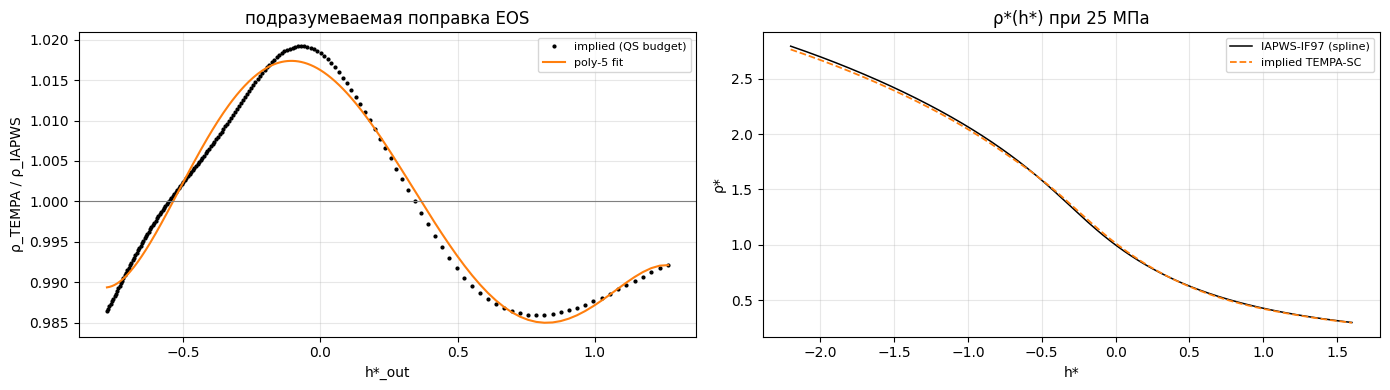

In [15]:
hs_l, r_l = [], []
for b in B:
    if b["hs"] > -0.8:
        r_need = 0.5 * case.kout * (b["G2rout"] * b["rout"]) / (case.dp_ch - b["fric"] - b["grav"] - b["kin"]) / b["rout"]
        hs_l.append(b["hs"]); r_l.append(r_need)
hs_l = np.array(hs_l); r_l = np.array(r_l)
_pc = np.polyfit(hs_l, r_l, 5)
r_eos = lambda hstar: np.polyval(_pc, np.clip(hstar, hs_l.min(), hs_l.max()))   # мультипликативная поправка к ρ*(h*), плоская вне диапазона
print("подразумеваемая ρ_TEMPA/ρ_IAPWS вдоль траектории (h*_out -> ratio):")
for k in range(0, len(hs_l), 12):
    print("   h*=%+.2f  ratio=%.3f" % (hs_l[k], r_l[k]))
print("полином 5-й степени: rms=%.4f" % np.sqrt(np.mean((np.polyval(_pc, hs_l) - r_l)**2)))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hs_l, r_l, 'k.', ms=4, label='implied (QS budget)'); ax[0].plot(hs_l, np.polyval(_pc, hs_l), color='tab:orange', lw=1.5, label='poly-5 fit')
ax[0].axhline(1, color='gray', lw=0.8); ax[0].set_xlabel('h*_out'); ax[0].set_ylabel('ρ_TEMPA / ρ_IAPWS'); ax[0].set_title('подразумеваемая поправка EOS'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
hs_g = np.linspace(-2.2, 1.6, 400)
rho_g, _ = physics.eos25(torch.tensor(hs_g)); rho_g = rho_g.numpy()
ax[1].plot(hs_g, rho_g, 'k', lw=1.1, label='IAPWS-IF97 (spline)'); ax[1].plot(hs_g, rho_g * r_eos(hs_g), '--', color='tab:orange', lw=1.3, label='implied TEMPA-SC')
ax[1].set_xlabel('h*'); ax[1].set_ylabel('ρ*'); ax[1].set_title('ρ*(h*) при 25 МПа'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
import dataclasses, math, time
from scipy.interpolate import CubicSpline

def make_case_friction(case, model):
    # тот же Case, только корреляция трения (Case.friction_model жёстко 'swamee' в build)
    if model == "blasius":
        lambda0 = 0.3164 / case.Re0**0.25
    elif model == "swamee":
        lambda0 = 0.25 / (np.log10(case.roughness / (3.7 * case.Dh) + 5.74 / case.Re0**0.9) ** 2)
    else:
        raise ValueError(model)
    Lam = lambda0 * case.L / (2.0 * case.Dh)
    return dataclasses.replace(case, friction_model=model, lambda0=lambda0, Lambda_ref=Lam, Lambda=Lam)

class TabulatedClosures:
    # ρ*(h*), χ=dρ*/dh* из physics.eos25 (ExtendedEOS25), μ(h) из mu_spline, λ(Re) как darcy_lambda_torch
    def __init__(self, physics, case, n=6000):
        self.case = case
        hs = np.linspace(-6.0, 70.0, n)
        with torch.no_grad():
            rho, chi = physics.eos25(torch.tensor(hs))
        self.hs = hs; self.rho_sp = CubicSpline(hs, rho.numpy())
        self.h_lo, self.h_hi = physics.eos25.h_lo, physics.eos25.h_hi
        self.mu_sp = mu_spline.spline
    def rho(self, hs, corr=None):
        hc = np.clip(hs, self.hs[0], self.hs[-1]); r = self.rho_sp(hc)
        return r if corr is None else r * corr(hc)
    def Lambda_dyn(self, G, hs, model):
        c = self.case
        h_abs = c.h_pc + c.Cp_pc / c.beta_pc * np.clip(hs, self.h_lo, self.h_hi)
        mu = self.mu_sp(np.clip(h_abs, mu_spline.h_grid[0], mu_spline.h_grid[-1]))
        Re = np.maximum(c.rho_pc * c.w0 * np.sqrt(G * G + 1e-12) * c.Dh / mu, 1.0)
        lam_l = 64.0 / Re
        if model == "blasius":
            lam_t = 0.3164 / Re**0.25
        else:
            lam_t = 0.25 / np.log10(c.roughness / c.Dh / 3.7 + 5.74 / Re**0.9) ** 2
        s = 1.0 / (1.0 + np.exp(-(Re - 2300.0) / 200.0))
        return ((1 - s) * lam_l + s * lam_t) * c.L / (2.0 * c.Dh)



In [17]:
class TempaFV:
    def __init__(self, physics, case, N=60, friction="blasius", acc=0.0, cons=True, eos_corr=None):
        self.ph, self.N, self.acc, self.cons, self.fmodel = physics, N, acc, cons, friction
        self.case = make_case_friction(case, friction)
        self.tab = TabulatedClosures(physics, self.case)
        self.corr = eos_corr
        self.dz = 1.0 / N
        self.h_in = -case.nspc
        self.rho_in = float(self.tab.rho(np.array([self.h_in]), self.corr)[0])

    def _dpc(self, Gin, G, rho, h):
        c, dz = self.case, self.dz
        Gout, rout = G[-1], rho[-1]                                   # донорная плотность последней ячейки
        Ld = self.tab.Lambda_dyn(G, h, self.fmodel)
        return (self.acc * (Gout**2 / rout - Gin**2 / self.rho_in)     # поток импульса (0 = телескопирован)
                + rho.sum() * dz / c.Fr                                # гравитация
                + np.sum(Ld * G * np.abs(G) / rho) * dz               # распределённое трение
                + 0.5 * c.kin * Gin * abs(Gin) / self.rho_in           # местные потери
                + 0.5 * c.kout * Gout * abs(Gout) / rout)

    def cold_steady_Gin(self):
        c = self.case
        f = lambda g: self._dpc(g, np.full(self.N, g), np.full(self.N, self.rho_in), np.full(self.N, self.h_in)) - c.dpi_star
        return brentq(f, 0.1, 10.0)

    def run(self, T=None, dt_sec=0.004, cfl=0.8, rec_dt_sec=0.1, n_snap=40, T_extend=None):
        c, N, dz = self.case, self.N, self.dz
        T = c.t_end_star if T is None else T
        dt = dt_sec * c.w0 / c.L
        nstep = int(round(T / dt)); nrec = max(1, int(round(rec_dt_sec / dt_sec)))
        h = np.full(N, self.h_in); Gin = self.cold_steady_Gin(); G = np.full(N, Gin); IG = Gin
        rho = self.tab.rho(h, self.corr)
        rec = {k: [] for k in ("t", "Gin", "Gout", "hout")}; snaps, snap_t = [], []
        for n in range(nstep):
            t = n * dt
            NQ = float(self.ph.NQ_prime(torch.tensor([t])).reshape(()))
            # --- энергия: явный donor-cell (дробление шага по материальному CFL) ---------------------
            Gp = np.maximum(G, 0.0)
            nsub = int(min(64, max(1, math.ceil((Gp / rho).max() * dt / dz / cfl))))   # ≤64: разнос после глубокого DWO не должен вешать расчёт
            dts = dt / nsub; hn = h; rho_s = rho
            for _ in range(nsub):
                hup = np.concatenate(([self.h_in], hn[:-1]))
                if self.cons:
                    Gf = np.concatenate(([Gin], Gp[:-1]))
                    E = rho_s * hn + dts * (NQ - (Gp * hn - Gf * hup) / dz)
                    rho_m = np.maximum(rho_s - dts * (Gp - Gf) / dz, 1e-3)
                    hn = E / rho_m
                else:
                    hn = hn + dts * (NQ - Gp * (hn - hup) / dz) / rho_s
                hn = np.clip(hn, self.tab.hs[0], self.tab.hs[-1])
                rho_s = self.tab.rho(hn, self.corr)
            rho_n = rho_s
            # --- неразрывность: G(z) = Gin − dz·cumsum(∂ρ/∂t) -------------------------------------
            GS = dz * np.cumsum((rho_n - rho) / dt); IS = GS.sum() * dz
            # --- интегральный импульс, явный Эйлер: (∫G dz)^{n+1} = (∫G dz)^n + dt(Δπ* − Δp) --------
            IG = IG + dt * (c.dpi_star - self._dpc(Gin, G, rho, h))
            Gin = float(np.clip(IG + IS, -20.0, 20.0))
            G = np.clip(Gin - GS, -20.0, 20.0); h = hn; rho = rho_n
            if not np.isfinite(Gin) or not np.all(np.isfinite(h)):
                print("   TempaFV: не-конечные значения при t=%.0f с — расчёт остановлен (глубокий DWO/разнос)" % (t * c.L / c.w0 + 2)); break
            if n % nrec == 0:
                rec["t"].append(t); rec["Gin"].append(Gin); rec["Gout"].append(G[-1]); rec["hout"].append(h[-1])
            if n % max(1, nstep // n_snap) == 0:
                snaps.append(h.copy()); snap_t.append(t)
        out = {k: np.asarray(v) for k, v in rec.items()}
        out["hsnap"] = np.asarray(snaps); out["tsnap"] = np.asarray(snap_t)
        out["Gin_kgs"] = out["Gin"] * c.rho_pc * c.w0 * c.A; out["Gout_kgs"] = out["Gout"] * c.rho_pc * c.w0 * c.A
        out["t_sec"] = out["t"] * c.L / c.w0 + 2.0     # абсолютное время бейзлайна (tau=0 при t=2 с)
        return out

def compare_to_baseline(out, label, ts=(20, 100, 500, 1000, 1400, 1600, 1700)):
    t, gi = out["t_sec"], out["Gin_kgs"]
    errs = [100 * (gi[np.searchsorted(t, T0)] / fib[np.searchsorted(tb, T0)] - 1) for T0 in ts]
    on = onset_time(t, gi)
    ntpc = None if on is None else float(np.interp(on, tb, Pb) / gi[np.searchsorted(t, on)] * case.beta_pc / case.Cp_pc)
    print("%-42s " % label + " ".join("%5d:%+6.2f%%" % (T0, e) for T0, e in zip(ts, errs))
          + "   onset=%s  NTPC=%s" % ("—" if on is None else "%.0f с" % on, "—" if ntpc is None else "%.3f" % ntpc))
    return errs, on, ntpc


In [18]:
# линейное продление рампы мощности за пределы файла (для onset после 1800 с)
_slope = float(np.polyfit(tb[tb > 20], Pb[tb > 20], 1)[0])
_tau_ext = np.append(forcing.tau, [2400.0 - 2.0]); _P_ext = np.append(forcing.power, [forcing.power[-1] + _slope * (2400.0 - forcing.time[-1])])
physics.forcing = dataclasses.replace(forcing, tau=_tau_ext, power=_P_ext,
                                      time=np.append(forcing.time, [2400.0]), flow_in=np.append(forcing.flow_in, [np.nan]),
                                      flow_out=np.append(forcing.flow_out, [np.nan]), ntpc=np.append(forcing.ntpc, [np.nan]))
T_star_2100 = (2100.0 - 2.0) * case.w0 / case.L



In [19]:
import numpy as np, torch, torch.nn as nn, math, time, os
from types import SimpleNamespace
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
torch.manual_seed(0)
P_DEG, P_CONV, R_E_H, R_S_H, UPWIND = 2, 0, 3.1, 0.2, True       # параметры Zhang + наша правка (донорные конвективные потоки)

def build_cloud(N_P=128, jitter=0.0, seed=0):
    """облако частиц + Type-B МНК-операторы граней (центральный A_C; наветренные A_L/A_R порядка P_CONV) — код v13/v13b, обёрнут в функцию, чтобы строить разные облака"""
    h = 1.0 / N_P; z_p = (np.arange(N_P) + 0.5) * h
    if jitter > 0:
        rng = np.random.default_rng(seed); z_p = np.clip(z_p + jitter * h * rng.uniform(-1, 1, N_P), 0.5*h*0.2, 1 - 0.5*h*0.2); z_p.sort()
    z_f = np.concatenate([[0.0], 0.5 * (z_p[1:] + z_p[:-1]), [1.0]]); V_i = np.diff(z_f); r_e, r_s = R_E_H * h, R_S_H * h
    def lsq_face_weights(zf, side=None, pdeg=None):
        pdeg = P_DEG if pdeg is None else pdeg
        d = z_p - zf; m = np.abs(d) < r_e
        if side == 'L': m &= (d < 0)
        if side == 'R': m &= (d > 0)
        idx = np.where(m)[0]
        if side is None and len(idx) < pdeg + 1: idx = np.argsort(np.abs(d))[:pdeg + 1]
        if side is not None and len(idx) == 0: idx = np.array([int(np.argmin(np.abs(d)))])
        if pdeg == 0: idx = np.array([idx[int(np.argmin(np.abs(d[idx])))]])
        p_eff = min(pdeg, len(idx) - 1); r = d[idx] / r_s
        w = (1.0 - np.abs(d[idx]) / r_e) ** 2 if len(idx) > p_eff + 1 else np.ones(len(idx))
        P = np.stack([r**k for k in range(p_eff + 1)], 1); M = P.T @ (w[:, None] * P)
        coef = np.linalg.solve(M + 1e-12*np.eye(p_eff+1), P.T * w); return idx, coef[0]
    def build_operator(side_fn, pdeg=None):
        A = np.zeros((len(z_f), N_P))
        for f, zf in enumerate(z_f):
            idx, wts = lsq_face_weights(zf, side_fn(f), pdeg); A[f, idx] = wts
        return torch.tensor(A, dtype=dtype, device=device)
    return SimpleNamespace(N=N_P, z_p=z_p, z_f=z_f, A_C=build_operator(lambda f: None), A_L=build_operator(lambda f: 'L', P_CONV), A_R=build_operator(lambda f: 'R', P_CONV),
                           zp=torch.tensor(z_p, dtype=dtype, device=device), Vi=torch.tensor(V_i, dtype=dtype, device=device), jitter=jitter)
cloud = build_cloud(128, 0.0)
print(f"регулярное облако: {cloud.N} частиц; шаблон грани: центральный {int((cloud.A_C[64]!=0).sum())} частиц, наветренный {int((cloud.A_L[64]!=0).sum())} (донор)")


регулярное облако: 128 частиц; шаблон грани: центральный 6 частиц, наветренный 1 (донор)


In [20]:
fv = TempaFV(physics, case, N=60, friction="blasius", acc=0.0, cons=True, eos_corr=r_eos)
case_fv, tab = fv.case, fv.tab
K_TIME, K_FLOW = case_fv.L / case_fv.w0, case_fv.rho_pc * case_fv.w0 * case_fv.A
h_in = -case_fv.nspc
_hs = torch.tensor(tab.hs, dtype=dtype, device=device); _rho = torch.tensor(tab.rho_sp(tab.hs) * r_eos(tab.hs), dtype=dtype, device=device)
def rho_of(hh):
    hc = hh.clamp(_hs[0], _hs[-1]); i = torch.searchsorted(_hs, hc.detach().contiguous(), right=True).clamp(1, _hs.numel() - 1)
    w = (hc - _hs[i-1]) / (_hs[i] - _hs[i-1]); return (1 - w) * _rho[i-1] + w * _rho[i]
rho_in = float(rho_of(torch.tensor([h_in], dtype=dtype, device=device))[0])
_mu_h = torch.tensor(mu_spline.h_grid, dtype=dtype, device=device); _mu_v = torch.tensor(mu_spline.mu_grid, dtype=dtype, device=device)
def Lambda_dyn(G, hh):
    h_abs = case_fv.h_pc + case_fv.Cp_pc / case_fv.beta_pc * hh.clamp(tab.h_lo, tab.h_hi)
    hc = h_abs.clamp(_mu_h[0], _mu_h[-1]); i = torch.searchsorted(_mu_h, hc.detach().contiguous(), right=True).clamp(1, _mu_h.numel() - 1)
    w = (hc - _mu_h[i-1]) / (_mu_h[i] - _mu_h[i-1]); mu = (1 - w) * _mu_v[i-1] + w * _mu_v[i]
    Re = torch.clamp(case_fv.rho_pc * case_fv.w0 * torch.sqrt(G * G + 1e-12) * case_fv.Dh / mu, min=1.0)
    s = torch.sigmoid((Re - 2300.0) / 200.0)
    return ((1 - s) * 64.0 / Re + s * 0.3164 / Re**0.25) * case_fv.L / (2.0 * case_fv.Dh)
T_END = (2100.0 - 2.0) / K_TIME
def NQ_at(t_star): return float(physics.NQ_prime(torch.tensor([t_star])).reshape(()))
print(f"K_TIME={K_TIME:.3f} s, K_FLOW={K_FLOW:.4f} kg/s, rho_in={rho_in:.4f}, T_END={T_END:.1f} t*")


K_TIME=2.125 s, K_FLOW=0.0349 kg/s, rho_in=2.6701, T_END=987.4 t*


## Гладкая ветвь — сеть v13 (upwind-LSFVP) как есть; её состояние на любом облаке + контроль огибающей

In [21]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__(); self.t_end_star = float(t_end_star); act = nn.Tanh if activation == "tanh" else nn.SiLU
        layers = []; in_dim = 2
        for i in range(depth): layers += [nn.Linear(in_dim if i == 0 else width, width), act()]
        self.net = nn.Sequential(*layers); self.head = nn.Linear(width, 3)
    def forward(self, z, t):
        x = torch.cat([2.0 * z - 1.0, 2.0 * t / self.t_end_star - 1.0], dim=1); y = self.head(self.net(x))
        return y[:, 0:1], y[:, 1:2], y[:, 2:3]
branch = SmoothPINN(t_end_star=T_END).to(device)
ck = torch.load("v13_upwind_lsfvp_up.pt", map_location=device, weights_only=False); branch.load_state_dict(ck["model"]); branch = branch.double().eval()
for p_ in branch.parameters(): p_.requires_grad_(False)
print(f"ветвь v13 загружена (UPWIND={ck.get('UPWIND')}, {len(ck['history'])} итераций обучения)")

@torch.no_grad()
def branch_state(t_star, cl):
    """состояние ветви сети на облаке cl: U = (h[N], G_in, ∫G dz); G_in — донорное значение на входной грани (ближайшая частица)"""
    Z = cl.zp.reshape(-1, 1); T = torch.full_like(Z, float(t_star))
    G_hat, h_hat, _ = branch(Z, T)
    G = (case_fv.G0_star * G_hat).reshape(-1); hh = (h_in + case_fv.nspc * Z * h_hat).reshape(-1)
    return torch.cat([hh, G[:1], (G * cl.Vi).sum().reshape(1)])

# --- TempaFV-ветвь (контроль оператора): плотные снимки h, G(z) = G_in − Σ ρ_t V_i ---
t0 = time.time()
ref = fv.run(T=T_END, dt_sec=0.004, rec_dt_sec=0.1, n_snap=2100)
print(f"TempaFV(r_eos) прогнан: {len(ref['tsnap'])} снимков, {time.time()-t0:.0f} s")
zc60 = (np.arange(60) + 0.5) / 60
def tempa_state(t_star, cl):
    ts, hs = ref["tsnap"], ref["hsnap"]; j = int(np.clip(np.searchsorted(ts, t_star) - 1, 0, len(ts) - 2))
    w = (t_star - ts[j]) / (ts[j+1] - ts[j]); hz = (1 - w) * hs[j] + w * hs[j+1]
    h_p = np.interp(cl.z_p, zc60, hz); h_p1 = np.interp(cl.z_p, zc60, hs[j+1]); h_p0 = np.interp(cl.z_p, zc60, hs[j])
    rho1 = rho_of(torch.tensor(h_p1, dtype=dtype, device=device)); rho0 = rho_of(torch.tensor(h_p0, dtype=dtype, device=device))
    rho_t = (rho1 - rho0) / (ts[j+1] - ts[j])
    Gin = float(np.interp(t_star, ref["t"], ref["Gin"])); G = Gin - torch.cumsum(rho_t * cl.Vi, 0)
    return torch.cat([torch.tensor(h_p, dtype=dtype, device=device), torch.tensor([Gin], dtype=dtype, device=device), (G * cl.Vi).sum().reshape(1)])

# контроль: огибающая расхода ветви сети vs TempaFV (как в v13)
tt = np.linspace(0, T_END, 2000); gin_net = np.array([float(branch_state(t, cloud)[cloud.N]) for t in tt]) * K_FLOW
tr, gr = ref["t_sec"], ref["Gin_kgs"]; m = tr <= 1750.0
env = float(np.mean(np.abs(np.interp(tr[m], tt * K_TIME + 2.0, gin_net) - gr[m])) / np.mean(np.abs(gr[m])))
print(f"огибающая ветви сети v13 vs TempaFV(r_eos), t<1750 s: {100*env:.2f}%")


ветвь v13 загружена (UPWIND=True, 40000 итераций обучения)
TempaFV(r_eos) прогнан: 2107 снимков, 88 s
огибающая ветви сети v13 vs TempaFV(r_eos), t<1750 s: 0.31%


## Линеаризуемый оператор: BE-шаг v13b на облаке, якобианы A = ∂R/∂U₁, B = ∂R/∂U₀, точный спектр отображения шага

точный спектр, ветвь СЕТИ v13 на облаке 128: t*(α=0) = 1727.8 s, период у порога 5.87 s
точный спектр, ветвь TempaFV на облаке 128: t*(α=0) = 1726.4 s, период у порога 5.88 s
(v15 на сетке TempaFV: 1804 s, период 4.7–5.3 s; TempaFV onset 1801 s, период 5.7 s)   [14 s]
  Δt=0.05 s: α(1790)=+0.1769 1/s, α(1820)=+0.2728 1/s, период 2.82 s
  Δt=0.2 s: α(1790)=+0.0451 1/s, α(1820)=+0.0693 1/s, период 11.33 s


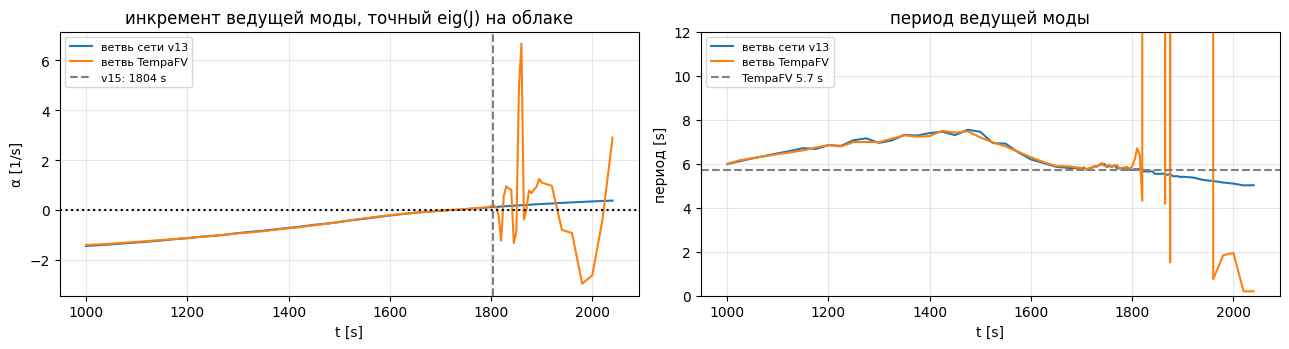

In [22]:
DT_SEC = 0.1; DT = DT_SEC / K_TIME                      # шаг линеаризации (как v12/v15)
def step_residual(U1, U0, t1_star, cl, dt=DT):
    """R(U₁,U₀) ∈ ℝ^{N+2}: (E) донорная энергия на частицах, (M) интегральный импульс, (IG) тождество ∫G = Σ G₁V_i; масштабы как в лоссе v13b"""
    N = cl.N; Vi = cl.Vi
    h1, Gin1, IG1 = U1[:N], U1[N], U1[N+1]; h0, Gin0, IG0 = U0[:N], U0[N], U0[N+1]
    rho1, rho0 = rho_of(h1), rho_of(h0); rho_t = (rho1 - rho0) / dt
    G1 = Gin1 - torch.cumsum(rho_t * Vi, 0)                                         # неразрывность (тождество)
    Gm, hm = G1.reshape(1, -1), h1.reshape(1, -1)
    G_f_c = (cl.A_C @ Gm.T).T; sgn = G_f_c
    G_f = torch.where(sgn >= 0, (cl.A_L @ Gm.T).T, (cl.A_R @ Gm.T).T) if UPWIND else G_f_c
    Gh_f = torch.where(sgn >= 0, (cl.A_L @ (Gm*hm).T).T, (cl.A_R @ (Gm*hm).T).T) if UPWIND else (cl.A_C @ (Gm*hm).T).T
    G_f = torch.cat([Gin1.reshape(1, 1), G_f[:, 1:]], 1); Gh_f = torch.cat([G_f[:, :1] * h_in, Gh_f[:, 1:]], 1)
    NQ = NQ_at(t1_star)
    R_E = (rho1 * h1 - rho0 * h0) / dt + ((Gh_f[0, 1:] - Gh_f[0, :-1]) / Vi - NQ)
    Gout, rout = G_f[0, -1], rho1[-1]
    dpc = (rho1 / case_fv.Fr * Vi).sum() + (Lambda_dyn(G1, h1) * G1 * G1.abs() / rho1 * Vi).sum() \
          + 0.5 * case_fv.kin * Gin1 * Gin1.abs() / rho_in + 0.5 * case_fv.kout * Gout * Gout.abs() / rout
    R_M = (IG1 - IG0) / dt - (case_fv.dpi_star - dpc)
    R_IG = IG1 - (G1 * Vi).sum()
    return torch.cat([R_E / case_fv.energy_scale, (R_M / case_fv.dpi_star).reshape(1), R_IG.reshape(1)])

def jacobians(t_sec, cl, state_fn):
    """A, B на ветви: U₀ = u_s(t), U₁ = u_s(t+Δt)"""
    t1 = (t_sec - 2.0) / K_TIME; U0, U1 = state_fn(t1, cl), state_fn(t1 + DT, cl)
    A, B = torch.autograd.functional.jacobian(lambda a, b: step_residual(a, b, t1 + DT, cl), (U1, U0), vectorize=True)
    return A, B

def lam_from_mu(mu):                                                   # λ [1/s] из μ отображения шага
    return torch.log(mu.to(torch.complex128)) / DT / K_TIME

def exact_spectrum(t_sec, cl, state_fn, n_lead=3):
    A, B = jacobians(t_sec, cl, state_fn)
    J = -torch.linalg.solve(A, B)
    mu, V = torch.linalg.eig(J.cpu())
    lam = lam_from_mu(mu); ok = torch.isfinite(lam.real)
    lam, V = lam[ok], V[:, ok]
    order = torch.argsort(lam.real, descending=True)
    return lam[order][:n_lead], V[:, order[:n_lead]], (A, B)

def sweep_exact(t_list, cl, state_fn, label):
    out = []
    for ts in t_list:
        lam, _, _ = exact_spectrum(ts, cl, state_fn)
        out.append((ts, float(lam[0].real), abs(float(lam[0].imag))))
    arr = np.array(out); a, w = arr[:, 1], arr[:, 2]
    k = np.where((a[:-1] < 0) & (a[1:] >= 0))[0]
    t_star = float(arr[k[0], 0] + (arr[k[0]+1, 0] - arr[k[0], 0]) * (-a[k[0]]) / (a[k[0]+1] - a[k[0]])) if len(k) else float("nan")
    w_star = float(np.interp(t_star, arr[:, 0], w)) if np.isfinite(t_star) else float("nan")
    print(f"{label}: t*(α=0) = {t_star:.1f} s, период у порога {2*np.pi/w_star if w_star>0 else float('nan'):.2f} s")
    return arr, t_star, w_star

t0 = time.time()
T_GRID = np.concatenate([np.arange(1000, 1700, 25.0), np.arange(1700, 1900, 5.0), np.arange(1900, 2060, 20.0)])
ex_net, tstar_net, wstar_net = sweep_exact(T_GRID, cloud, branch_state, "точный спектр, ветвь СЕТИ v13 на облаке 128")
ex_fv, tstar_fv, wstar_fv = sweep_exact(T_GRID, cloud, tempa_state, "точный спектр, ветвь TempaFV на облаке 128")
print(f"(v15 на сетке TempaFV: 1804 s, период 4.7–5.3 s; TempaFV onset 1801 s, период 5.7 s)   [{time.time()-t0:.0f} s]")
# чувствительность к Δt линеаризации в двух точках
for dts in (0.05, 0.2):
    DT_save = DT; DT = dts / K_TIME
    l1, _, _ = exact_spectrum(1790.0, cloud, branch_state); l2, _, _ = exact_spectrum(1820.0, cloud, branch_state)
    print(f"  Δt={dts} s: α(1790)={float(l1[0].real):+.4f} 1/s, α(1820)={float(l2[0].real):+.4f} 1/s, период {2*np.pi/abs(float(l2[0].imag)):.2f} s")
    DT = DT_save
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for arr, lab, c in [(ex_net, "ветвь сети v13", "tab:blue"), (ex_fv, "ветвь TempaFV", "tab:orange")]:
    ax[0].plot(arr[:, 0], arr[:, 1], "-", color=c, label=lab); ax[1].plot(arr[:, 0], 2*np.pi/np.maximum(arr[:, 2], 1e-9), "-", color=c, label=lab)
ax[0].axhline(0, color="k", ls=":"); ax[0].axvline(1804, color="gray", ls="--", label="v15: 1804 s"); ax[0].set_ylabel("α [1/s]"); ax[0].set_title("инкремент ведущей моды, точный eig(J) на облаке")
ax[1].axhline(5.7, color="gray", ls="--", label="TempaFV 5.7 s"); ax[1].set_ylim(0, 12); ax[1].set_ylabel("период [s]"); ax[1].set_title("период ведущей моды")
for a_ in ax: a_.set_xlabel("t [s]"); a_.grid(alpha=0.3); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()


## SubspaceNet: Q(z,t) → ортонормировка на облаке → лосс инвариантности → Ритц K×K

банк якобианов: 400 моментов, 11 s
it     1  L_inv=2.208e-01   (0 s)


/var/tmp/ipykernel_444754/2388032905.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  hist.append(float(L))


it   500  L_inv=2.543e-04   (35 s)
it  1000  L_inv=1.569e-04   (70 s)
it  1500  L_inv=1.281e-04   (105 s)
it  2000  L_inv=8.857e-05   (140 s)
it  2500  L_inv=7.577e-05   (175 s)
it  3000  L_inv=7.317e-05   (210 s)
it  3500  L_inv=5.910e-05   (246 s)
it  4000  L_inv=6.363e-05   (281 s)


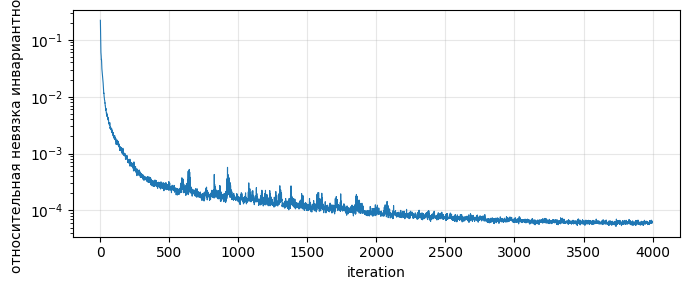

In [23]:
K_SUB = 6
class SubspaceNet(nn.Module):
    """K базисных функций: h-часть q_k(z,t) (RFF по z + t), скалярные части (G_in, ∫G) — MLP по t; выход — (N+2)×K, ортонормированный QR на облаке"""
    def __init__(self, K=K_SUB, m=16, sigma=2.0, width=64, seed=0):
        super().__init__(); gen = torch.Generator().manual_seed(seed); self.K = K
        self.register_buffer("kz", torch.randn(m, generator=gen).to(dtype) * sigma)
        self.fz = nn.Sequential(nn.Linear(2*m + 2, width), nn.Tanh(), nn.Linear(width, width), nn.Tanh(), nn.Linear(width, width), nn.Tanh(), nn.Linear(width, K)).to(dtype)
        self.fs = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 2*K)).to(dtype)
    def raw(self, cl, t_star):
        z = cl.zp.reshape(-1, 1); ts = torch.full_like(z, 2.0 * float(t_star) / T_END - 1.0)
        arg = 2 * math.pi * z * self.kz.reshape(1, -1)
        qh = self.fz(torch.cat([torch.cos(arg), torch.sin(arg), 2*z - 1, ts], 1))            # (N,K)
        qs = self.fs(ts[:1]).reshape(2, self.K)                                                # (2,K)
        return torch.cat([qh, qs], 0)                                                          # (N+2,K)
    def forward(self, cl, t_star):
        Q, _ = torch.linalg.qr(self.raw(cl, t_star)); return Q

def ritz(Q, A, B):
    """S = −(QᵀAQ)⁻¹(QᵀBQ); собственные μ отображения шага в подпространстве; невязка инвариантности"""
    AQ, BQ = A @ Q, B @ Q
    A_K, B_K = Q.T @ AQ, Q.T @ BQ
    S = -torch.linalg.solve(A_K, B_K)
    res = BQ + AQ @ S
    return S, (res**2).sum() / (BQ**2).sum()

def ritz_leading(Q, A, B):
    S, rel = ritz(Q, A, B); mu, C = torch.linalg.eig(S.detach().cpu()); lam = lam_from_mu(mu)
    k = int(torch.argmax(lam.real)); return lam[k], (Q.detach().cpu().to(torch.complex128) @ C[:, k]), float(rel)

# --- банк якобианов на ветви сети (регулярное облако), t ∈ [1000, 2060] s ---
t0 = time.time(); rng = np.random.default_rng(0)
T_BANK = np.sort(np.concatenate([rng.uniform(1000, 2060, 360), np.linspace(1750, 1860, 40)]))
BANK = [jacobians(ts, cloud, branch_state) for ts in T_BANK]
print(f"банк якобианов: {len(BANK)} моментов, {time.time()-t0:.0f} s")

snet = SubspaceNet().to(device)
opt = torch.optim.Adam(snet.parameters(), lr=2e-3); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 4000, eta_min=1e-4)
hist = []; t0 = time.time()
for it in range(1, 4001):
    idx = rng.choice(len(BANK), 32, replace=False); L = 0.0
    for j in idx:
        A, B = BANK[j]; Q = snet(cloud, (T_BANK[j] - 2.0) / K_TIME); _, rel = ritz(Q, A, B); L = L + rel
    L = L / len(idx); opt.zero_grad(set_to_none=True); L.backward(); torch.nn.utils.clip_grad_norm_(snet.parameters(), 1.0); opt.step(); sched.step()
    hist.append(float(L))
    if it % 500 == 0 or it == 1: print(f"it {it:5d}  L_inv={float(L):.3e}   ({time.time()-t0:.0f} s)", flush=True)
torch.save({"model": snet.state_dict(), "hist": hist, "K": K_SUB}, "v19_subspace.pt")
plt.figure(figsize=(7, 3)); plt.semilogy(hist, lw=0.8); plt.xlabel("iteration"); plt.ylabel("относительная невязка инвариантности"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Валидация Ритца против точного спектра: α(t), ω(t), t*, период, угол подпространства

регулярное облако 128 (обучение): t* Ритц nan s vs eig 1727.4 s (Δ +nan s, ворота ±10 s: FAIL); период Ритц nan s vs eig 5.84 s (+nan%, ±5%: FAIL); sinΘ у порога max 0.212 (≤0.05: FAIL), L_inv у порога max 6.2e-05


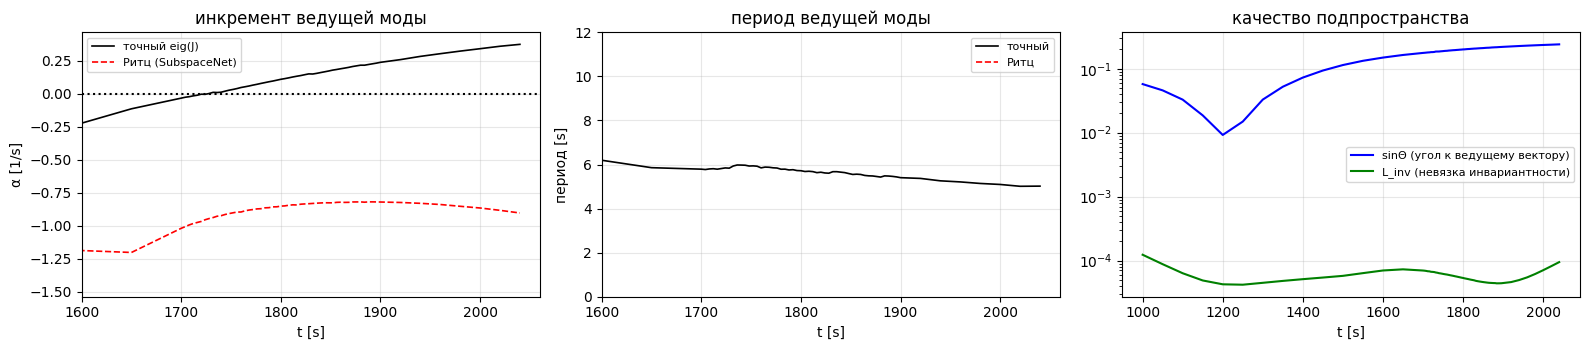

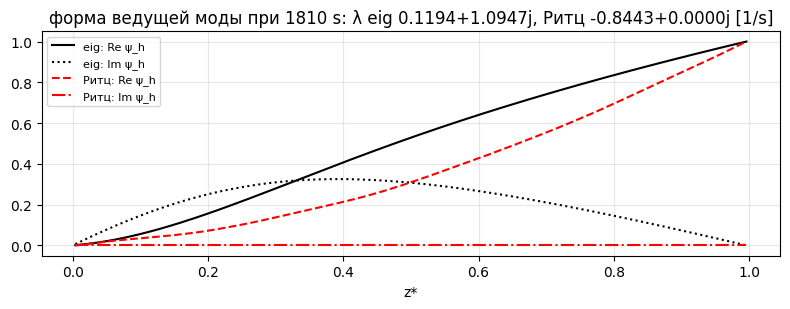

In [24]:
def sweep_ritz(t_list, cl, state_fn, label, with_exact=True):
    rows = []
    for ts in t_list:
        A, B = jacobians(ts, cl, state_fn)
        with torch.no_grad(): Q = snet(cl, (ts - 2.0) / K_TIME)
        lam_r, v_r, rel = ritz_leading(Q, A, B)
        if with_exact:
            J = -torch.linalg.solve(A, B); mu, V = torch.linalg.eig(J.cpu()); lam = lam_from_mu(mu); ok = torch.isfinite(lam.real); lam, V = lam[ok], V[:, ok]
            k = int(torch.argmax(lam.real)); le, ve = lam[k], V[:, k]
            Qc = Q.cpu(); Pv = lambda v: v - Qc.to(torch.complex128) @ (Qc.T.to(torch.complex128) @ v)
            sinT = max(float(torch.linalg.norm(Pv(ve.real.to(torch.complex128)))) / max(float(torch.linalg.norm(ve.real)), 1e-30),
                       float(torch.linalg.norm(Pv(ve.imag.to(torch.complex128)))) / max(float(torch.linalg.norm(ve.imag)), 1e-30))
        else: le, sinT = complex(float("nan"), float("nan")), float("nan")
        rows.append((ts, float(lam_r.real), abs(float(lam_r.imag)), float(le.real), abs(float(le.imag)), sinT, rel))
    arr = np.array(rows)
    def zero_cross(t, a):
        k = np.where((a[:-1] < 0) & (a[1:] >= 0))[0]
        return float(t[k[0]] + (t[k[0]+1] - t[k[0]]) * (-a[k[0]]) / (a[k[0]+1] - a[k[0]])) if len(k) else float("nan")
    t_r, t_e = zero_cross(arr[:, 0], arr[:, 1]), zero_cross(arr[:, 0], arr[:, 3])
    w_r, w_e = float(np.interp(t_r, arr[:, 0], arr[:, 2])), float(np.interp(t_e, arr[:, 0], arr[:, 4])) if np.isfinite(t_e) else float("nan")
    near = (arr[:, 0] > 1750) & (arr[:, 0] < 1860)
    print(f"{label}: t* Ритц {t_r:.1f} s vs eig {t_e:.1f} s (Δ {t_r-t_e:+.1f} s, ворота ±10 s: {'PASS' if abs(t_r-t_e)<=10 else 'FAIL'});"
          f" период Ритц {2*np.pi/w_r:.2f} s vs eig {2*np.pi/w_e:.2f} s ({100*(w_r/w_e-1):+.1f}%, ±5%: {'PASS' if abs(w_r/w_e-1)<=0.05 else 'FAIL'});"
          f" sinΘ у порога max {arr[near, 5].max():.3f} (≤0.05: {'PASS' if arr[near,5].max()<=0.05 else 'FAIL'}), L_inv у порога max {arr[near, 6].max():.1e}")
    return arr, (t_r, t_e, w_r, w_e)

T_VAL = np.concatenate([np.arange(1000, 1700, 50.0), np.arange(1700, 1900, 4.0), np.arange(1900, 2060, 20.0)])
val_reg, g_reg = sweep_ritz(T_VAL, cloud, branch_state, "регулярное облако 128 (обучение)")
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
ax[0].plot(val_reg[:, 0], val_reg[:, 3], "k-", lw=1.2, label="точный eig(J)"); ax[0].plot(val_reg[:, 0], val_reg[:, 1], "r--", lw=1.2, label="Ритц (SubspaceNet)")
ax[0].axhline(0, color="k", ls=":"); ax[0].set_ylabel("α [1/s]"); ax[0].set_title("инкремент ведущей моды"); ax[0].set_xlim(1600, 2060)
ax[1].plot(val_reg[:, 0], 2*np.pi/np.maximum(val_reg[:, 4], 1e-9), "k-", lw=1.2, label="точный"); ax[1].plot(val_reg[:, 0], 2*np.pi/np.maximum(val_reg[:, 2], 1e-9), "r--", lw=1.2, label="Ритц")
ax[1].set_ylim(0, 12); ax[1].set_ylabel("период [s]"); ax[1].set_title("период ведущей моды"); ax[1].set_xlim(1600, 2060)
ax[2].semilogy(val_reg[:, 0], val_reg[:, 5], "b-", label="sinΘ (угол к ведущему вектору)"); ax[2].semilogy(val_reg[:, 0], val_reg[:, 6], "g-", label="L_inv (невязка инвариантности)"); ax[2].set_title("качество подпространства")
for a_ in ax: a_.set_xlabel("t [s]"); a_.grid(alpha=0.3); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()
# форма ведущей моды у порога: ψ_h(z)
A, B = jacobians(1810.0, cloud, branch_state)
with torch.no_grad(): Q = snet(cloud, (1810.0 - 2.0) / K_TIME)
lam_r, v_r, _ = ritz_leading(Q, A, B); J = -torch.linalg.solve(A, B); mu, V = torch.linalg.eig(J.cpu()); lam = lam_from_mu(mu); k = int(torch.argmax(torch.nan_to_num(lam.real, nan=-1e9))); ve = V[:, k]
ph = lambda v: v / v[torch.argmax(v.abs())]
plt.figure(figsize=(8, 3.2)); plt.plot(cloud.z_p, ph(ve[:cloud.N]).real, "k-", label="eig: Re ψ_h"); plt.plot(cloud.z_p, ph(ve[:cloud.N]).imag, "k:", label="eig: Im ψ_h")
plt.plot(cloud.z_p, ph(v_r[:cloud.N]).real, "r--", label="Ритц: Re ψ_h"); plt.plot(cloud.z_p, ph(v_r[:cloud.N]).imag, "r-.", label="Ритц: Im ψ_h")
plt.xlabel("z*"); plt.title(f"форма ведущей моды при 1810 s: λ eig {complex(lam[k]):.4f}, Ритц {complex(lam_r):.4f} [1/s]"); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Бессеточность: та же обученная Q на джиттер-облаке и на облаке другого размера (оператор пересобран, сеть не переобучалась)

джиттер-облако 128 (0.45h): t* Ритц nan s vs eig 1727.3 s (Δ +nan s, ворота ±10 s: FAIL); период Ритц nan s vs eig 5.83 s (+nan%, ±5%: FAIL); sinΘ у порога max 0.212 (≤0.05: FAIL), L_inv у порога max 1.0e-02
облако 200 частиц (джиттер 0.3h): t* Ритц nan s vs eig 1721.7 s (Δ +nan s, ворота ±10 s: FAIL); период Ритц nan s vs eig 5.81 s (+nan%, ±5%: FAIL); sinΘ у порога max 0.180 (≤0.05: FAIL), L_inv у порога max 4.7e-03

Сводка порога t*(α=0) и периода по всем облакам (ветвь сети v13; эталоны: v15 1804 s / 4.7–5.3 s; TempaFV 1801 s / 5.7 s):
  регулярное 128  : Ритц t*=nan s, период nan s | eig t*=1727.4 s, период 5.84 s
  джиттер 128     : Ритц t*=nan s, период nan s | eig t*=1727.3 s, период 5.83 s
  200 частиц      : Ритц t*=nan s, период nan s | eig t*=1721.7 s, период 5.81 s


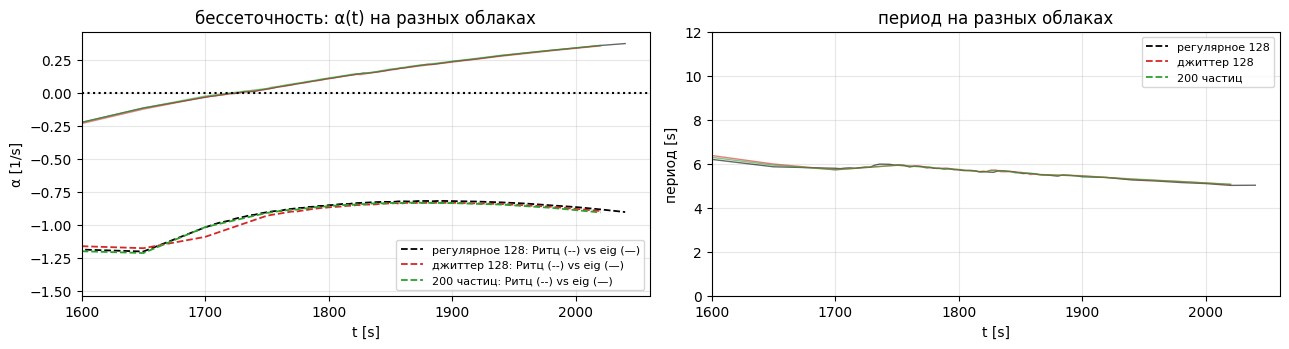

In [25]:
cloud_j = build_cloud(128, jitter=0.45, seed=1)
cloud_n = build_cloud(200, jitter=0.3, seed=2)
T_M = np.concatenate([np.arange(1600, 1750, 50.0), np.arange(1750, 1870, 4.0), np.arange(1900, 2060, 40.0)])
val_j, g_j = sweep_ritz(T_M, cloud_j, branch_state, "джиттер-облако 128 (0.45h)")
val_n, g_n = sweep_ritz(T_M, cloud_n, branch_state, "облако 200 частиц (джиттер 0.3h)")
print("\nСводка порога t*(α=0) и периода по всем облакам (ветвь сети v13; эталоны: v15 1804 s / 4.7–5.3 s; TempaFV 1801 s / 5.7 s):")
for lab, g in [("регулярное 128", g_reg), ("джиттер 128", g_j), ("200 частиц", g_n)]:
    print(f"  {lab:16s}: Ритц t*={g[0]:.1f} s, период {2*np.pi/g[2]:.2f} s | eig t*={g[1]:.1f} s, период {2*np.pi/g[3]:.2f} s")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
for arr, lab, c in [(val_reg, "регулярное 128", "k"), (val_j, "джиттер 128", "tab:red"), (val_n, "200 частиц", "tab:green")]:
    ax[0].plot(arr[:, 0], arr[:, 3], "-", color=c, lw=1, alpha=0.6); ax[0].plot(arr[:, 0], arr[:, 1], "--", color=c, lw=1.3, label=f"{lab}: Ритц (--) vs eig (—)")
    ax[1].plot(arr[:, 0], 2*np.pi/np.maximum(arr[:, 4], 1e-9), "-", color=c, lw=1, alpha=0.6); ax[1].plot(arr[:, 0], 2*np.pi/np.maximum(arr[:, 2], 1e-9), "--", color=c, lw=1.3, label=lab)
ax[0].axhline(0, color="k", ls=":"); ax[0].set_xlim(1600, 2060); ax[0].set_ylabel("α [1/s]"); ax[0].set_title("бессеточность: α(t) на разных облаках")
ax[1].set_xlim(1600, 2060); ax[1].set_ylim(0, 12); ax[1].set_ylabel("период [s]"); ax[1].set_title("период на разных облаках")
for a_ in ax: a_.set_xlabel("t [s]"); a_.grid(alpha=0.3); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Выводы (заполняются прогоном)

Что проверено: (1) точный спектр линеаризованного BE-шага LSFVP на облаке даёт порог и период DWO на ветви TempaFV и на ветви сети v13 — оператор содержит неустойчивость, ветвь сети её не искажает; (2) SubspaceNet выучивает инвариантное подпространство, Ритц K×K воспроизводит α(t), ω(t), t* и форму моды; (3) та же сеть на других облаках — бессеточность. Роль сети: непрерывность по z и t (следующий шаг — параметры режима p).
